In [135]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [136]:
df = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

**Objective: perform comparitive analysis of hospital admission records for diabetic patients based on two or more comparison points**

In [ ]:
df.shape

(101766, 50)

In [ ]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [ ]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [144]:
# Selecting to keep only necessary columns for analysis
selected_columns = ['patient_nbr', 'race', 'gender', 'age', 'time_in_hospital', 'readmitted']
new_df = df[selected_columns].copy()
new_df.head()

,patient_nbr,race,gender,age,time_in_hospital,readmitted
0,8222157,Caucasian,Female,[0-10),1,NO
1,55629189,Caucasian,Female,[10-20),3,>30
2,86047875,AfricanAmerican,Female,[20-30),2,NO
3,82442376,Caucasian,Male,[30-40),2,NO
4,42519267,Caucasian,Male,[40-50),1,NO


In [145]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   patient_nbr       101766 non-null  int64 
 1   race              101766 non-null  object
 2   gender            101766 non-null  object
 3   age               101766 non-null  object
 4   time_in_hospital  101766 non-null  int64 
 5   readmitted        101766 non-null  object
dtypes: int64(2), object(4)
memory usage: 4.7+ MB


In [158]:
# Grouping by race
df.groupby(['race'])['patient_nbr'].count().sort_values(ascending=False)

,patient_nbr
race,
Caucasian,76099
AfricanAmerican,19210
?,2273
Hispanic,2037
Other,1506
Asian,641


In [165]:
# Converting race stats to percentage as decimals
race_percent = df['race'].value_counts(normalize=True) * 100
print(race_percent.sort_values(ascending=False))

race
Caucasian          74.778413
AfricanAmerican    18.876639
?                   2.233555
Hispanic            2.001651
Other               1.479866
Asian               0.629876
Name: proportion, dtype: float64


<Axes: ylabel='proportion'>

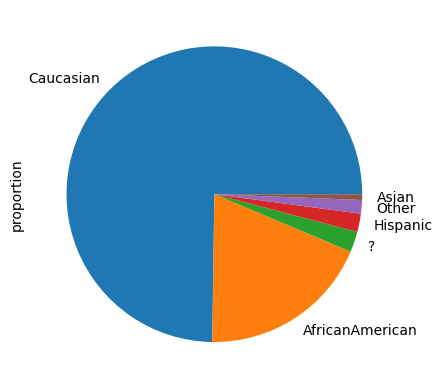

In [167]:
race_percent.plot(kind='pie')
# Insight: the plot reveals that Caucasian patients have the highest number of admissions, followed by AfricanAmerican

<Axes: ylabel='time_in_hospital'>

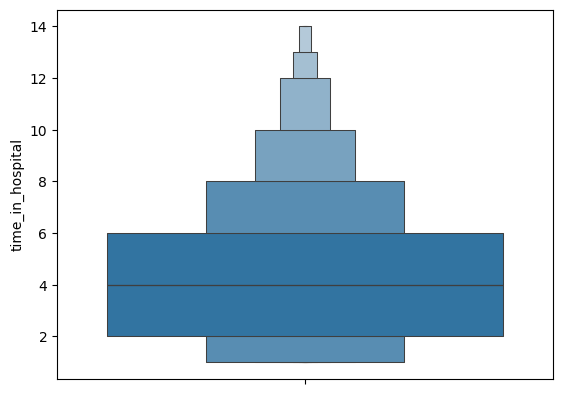

In [139]:
sns.boxenplot(new_df['time_in_hospital'])
# Insight: the plot reveals that the median time spent while admitted to the hospital is 4 days, and most frequently between 2 and 6 days

<Axes: xlabel='age'>

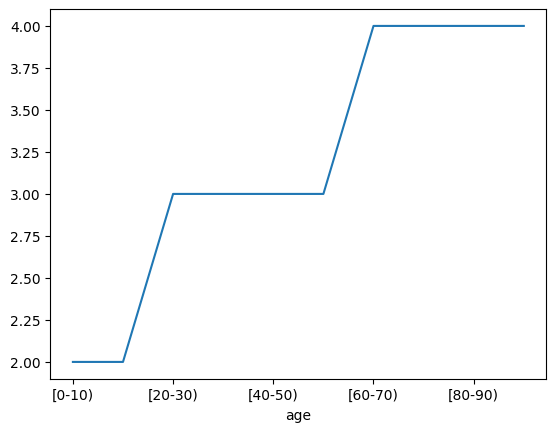

In [140]:
new_df.groupby(['age'])['time_in_hospital'].median().plot(kind='line')
# Insight: the plot reveals that the average time spent while admitted to the hospital increases with age

<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

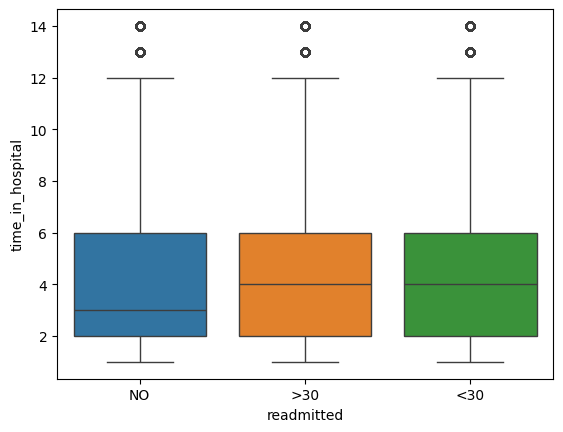

In [141]:
sns.boxplot(x='readmitted', y='time_in_hospital', data=new_df, hue='readmitted')
# Insight: the plot reveals that newly admitted patients tend to spend, on average, less time in the hospital than those who end up being readmitted

In [142]:
# Creating two separate data frames for male and female patients
female = new_df[new_df['gender'] == "Female"]
male = new_df[new_df['gender'] == "Male"]

/tmp/ipykernel_881/2373722360.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  female['Source'] = 'Female'
/tmp/ipykernel_881/2373722360.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  male['Source'] = 'Male'


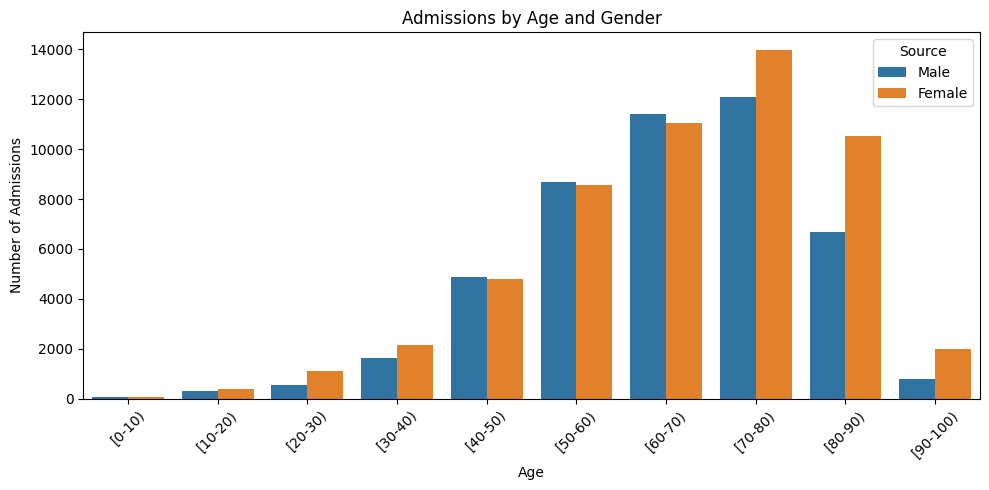

In [143]:
# Creating a combination plot to show the trend in hospital admissions by age and gender
female['Source'] = 'Female'
male['Source'] = 'Male'
combined_df = pd.concat([male, female], ignore_index=True)
sorted_by_age = sorted(combined_df['age'].unique())

plt.figure(figsize=(10, 5))
# Create the countplot
sns.countplot(
    data=combined_df,
    x='age',
    hue='Source',  # Splits bars by Female/Male
    order=sorted(combined_df['age'].unique()) # Ensures age is sorted
)

# Customize the plot
plt.title('Admissions by Age and Gender')
plt.ylabel('Number of Admissions')
plt.xlabel('Age')
plt.xticks(rotation=45) # Rotates x-labels if there are many ages
plt.tight_layout()

# Show the plot
plt.show()

# Insight: the plot reveals that the number of hospital admissions increases progressively with the increase of patients' age (from age 0 to 80).
# Admission numbers drop dramatically for age groups of 80-90 and 90-100
# The plot also reveals higher hospital admission numbers for patients identifying themselves as 'female' than those identifying as 'male' in the age groups of 70-100

**Analysis summary: the analysis focused on the key features of race, gender and age and explored the trends associated with time spent in hospital while admitted and readmission stats. It reveals the following:**

**- hospital admissions for diabetic patients are disproportionally higher for Caucasian patients - at almost 75%; however, this may be due to particular population distribution and general access to healthcare as opposed to higher risk of diabetes**

**-average hospital stay duration is between 2 and 6 days, with 4 days being the most common**

**-hospital stay duration increases with age (slower recovery for senior patients?)**

**-patients who are readmitted tend to have longer hospital stays, possibly due to higher risk of complications**

**-admission numbers fall dramatically for patients age >80; however, this could be mainly due to life expectancy**

**-female patients lead admission numbers for age 70+; possibly due to generally famale's longer life expectancy**